In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
for dirpath, dirnames, filenames in os.walk("/content/drive/MyDrive/UAS ML Teo 2025"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 4 directories and 2 images in '/content/drive/MyDrive/UAS ML Teo 2025'.
There are 6 directories and 0 images in '/content/drive/MyDrive/UAS ML Teo 2025/test'.
There are 0 directories and 31 images in '/content/drive/MyDrive/UAS ML Teo 2025/test/eru'.
There are 0 directories and 47 images in '/content/drive/MyDrive/UAS ML Teo 2025/test/waakye'.
There are 0 directories and 31 images in '/content/drive/MyDrive/UAS ML Teo 2025/test/ekwang'.
There are 0 directories and 52 images in '/content/drive/MyDrive/UAS ML Teo 2025/test/jollof-ghana'.
There are 0 directories and 31 images in '/content/drive/MyDrive/UAS ML Teo 2025/test/ndole'.
There are 0 directories and 59 images in '/content/drive/MyDrive/UAS ML Teo 2025/test/palm-nut-soup'.
There are 0 directories and 1754 images in '/content/drive/MyDrive/UAS ML Teo 2025/Fulll dataset'.
There are 6 directories and 0 images in '/content/drive/MyDrive/UAS ML Teo 2025/train'.
There are 0 directories and 274 images in '/content/drive/MyDrive

In [ ]:
import pathlib
import numpy as np
data_dir = pathlib.Path("/content/drive/MyDrive/UAS ML Teo 2025/train")
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['ekwang' 'eru' 'jollof-ghana' 'ndole' 'palm-nut-soup' 'waakye']


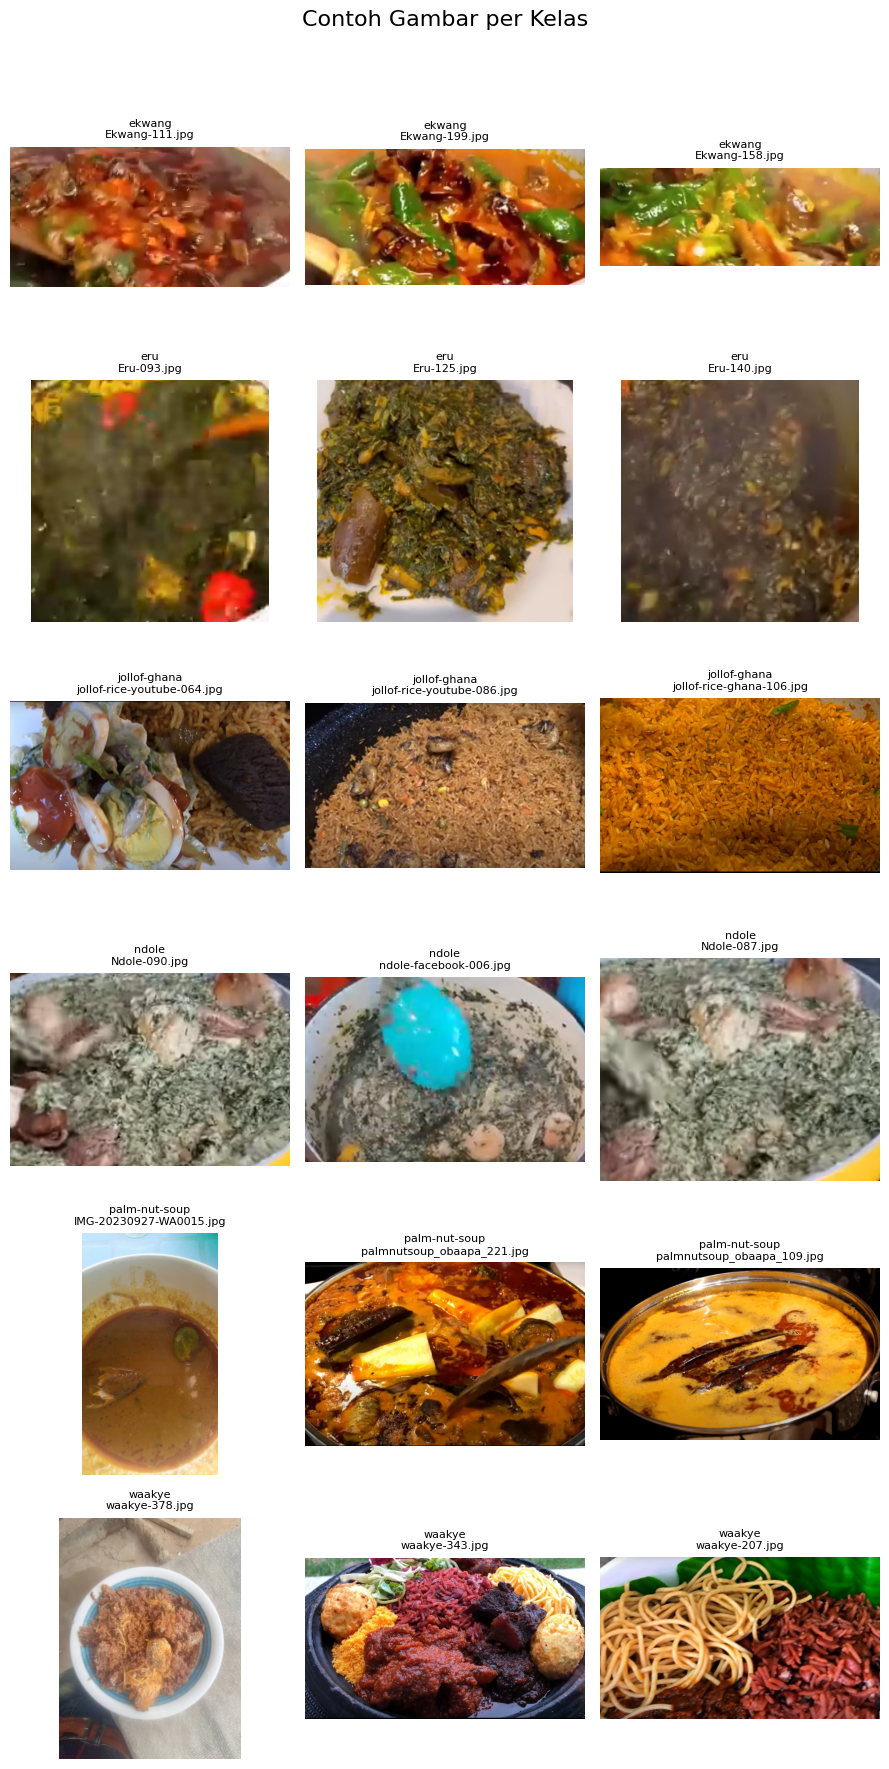

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Daftar kelas berdasarkan nama sub-folder di train/
train_root = '/content/drive/MyDrive/UAS ML Teo 2025/train'
classes = [d for d in os.listdir(train_root) if os.path.isdir(os.path.join(train_root, d))]

# 2. Tentukan jumlah sampel per kelas (misal 3)
n_per_class = 3

# 3. Buat figure dengan ukuran yang cukup besar
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 3))
fig.suptitle('Contoh Gambar per Kelas', fontsize=16)

for i, cls in enumerate(sorted(classes)):
    cls_dir = os.path.join(train_root, cls)
    all_imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Jika jumlah gambar kurang dari n_per_class, tampilkan semua
    samples = random.sample(all_imgs, min(n_per_class, len(all_imgs)))

    for j, fname in enumerate(samples):
        img_path = os.path.join(cls_dir, fname)
        img = Image.open(img_path).convert('RGB')

        ax = axes[i, j] if len(classes) > 1 else axes[j]
        ax.imshow(img)
        ax.axis('off')

        # Tampilkan nama file di bawah gambar
        ax.set_title(f"{cls}\n{fname}", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


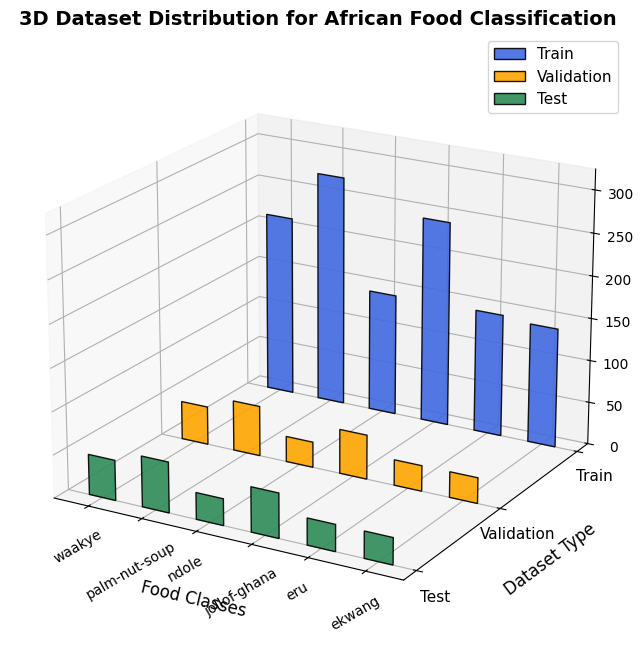

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Path ke folder train, val, test
base_dir = '/content/drive/MyDrive/UAS ML Teo 2025'
folders = {'Train': 'train', 'Validation': 'val', 'Test': 'test'}

# Dapatkan daftar kelas dari salah satu folder (misal train)
class_names = sorted(os.listdir(os.path.join(base_dir, 'train')))

# Hitung jumlah gambar per kelas per folder
class_counts = {key: [] for key in folders}

for set_name, folder_name in folders.items():
    for cls in class_names:
        folder = os.path.join(base_dir, folder_name, cls)
        if os.path.exists(folder):
            count = len([
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
        else:
            count = 0
        class_counts[set_name].append(count)

# Persiapkan data untuk visualisasi
x = np.arange(len(class_names))  # Posisi kelas
y_labels = list(folders.keys())  # ['Train', 'Validation', 'Test']
y_pos = np.arange(len(y_labels))  # [0, 1, 2]
colors = ['royalblue', 'orange', 'seagreen']
zdir = 'y'

# Buat visualisasi 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot setiap set (train, val, test)
for i, set_name in enumerate(y_labels):
    ax.bar(
        x,
        class_counts[set_name],
        zs=i,
        zdir=zdir,
        width=0.5,
        color=colors[i],
        alpha=0.9,
        edgecolor='black',
        label=set_name
    )

# Label dan tampilan
ax.set_xlabel('Food Classes', fontsize=12, labelpad=12)
ax.set_ylabel('Dataset Type', fontsize=12, labelpad=12)
ax.set_zlabel('Number of Images', fontsize=12, labelpad=12)
ax.set_title('3D Dataset Distribution for African Food Classification', fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, fontsize=10)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=11)
ax.set_zlim(0, max([max(v) for v in class_counts.values()]) + 50)

ax.view_init(elev=20, azim=120)
ax.legend(loc='upper right', fontsize=11)

plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder train: /content/drive/MyDrive/UAS ML Teo 2025/train
Folder val  : /content/drive/MyDrive/UAS ML Teo 2025/val
Folder test : /content/drive/MyDrive/UAS ML Teo 2025/test

Total gambar Train+Val: 1407
Total gambar Test     : 251

Dimensi X_train: (1407, 30000)
Dimensi X_test : (251, 30000)

Model SVM (RBF, C=1.0, gamma='scale', degree=3) berhasil dilatih.

Confusion Matrix (baris=aktual, kolom=prediksi):
[[22  3  1  0  4  1]
 [ 0 28  1  0  1  1]
 [ 1  0 40  0  9  2]
 [ 0  1  1 26  3  0]
 [ 1  0  5  0 51  2]
 [ 0  0  2  0  2 43]]

Classification Report:
               precision    recall  f1-score   support

       ekwang     0.9167    0.7097    0.8000        31
          eru     0.8750    0.9032    0.8889        31
 jollof-ghana     0.8000    0.7692    0.7843        52
        ndole     1.0000    0.8387    0.9123        31
palm-nut-soup     0.7286    0.864

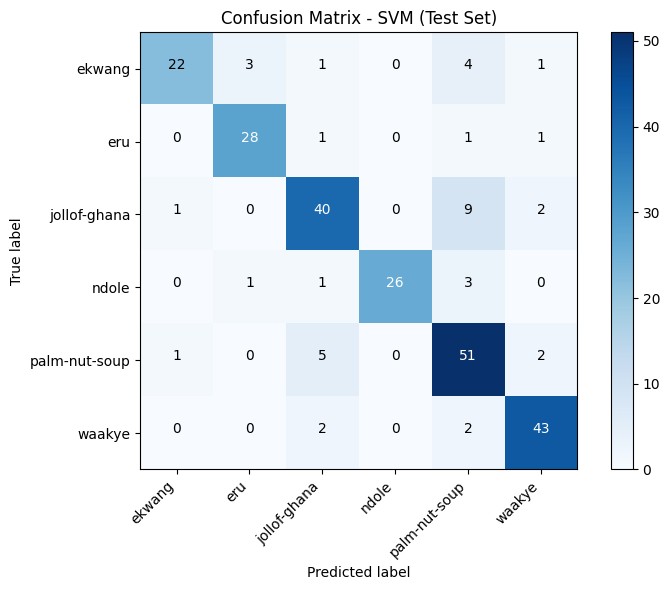

In [ ]:
# 1. Mount Google Drive dan Pasang Library
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Pasang library yang diperlukan
!pip install openpyxl

import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 2. Atur Path ke Folder Train / Val / Test
base_dir = '/content/drive/MyDrive/UAS ML Teo 2025'

data_dir_train = os.path.join(base_dir, 'train')
data_dir_val   = os.path.join(base_dir, 'val')
data_dir_test  = os.path.join(base_dir, 'test')

print("Folder train:", data_dir_train)
print("Folder val  :", data_dir_val)
print("Folder test :", data_dir_test)

# 3. Fungsi Bantu: Muat Gambar dan Konversi Label
def list_images_in_folder(folder_path):
    """

    Input:
      folder_path = path root yang berisi sub‑folder kelas (misal 'train/').
    Output:
      dua list: (list_paths, list_labels)
       - list_paths: daftar full path tiap gambar
       - list_labels: label (nama subfolder) sesuai file
    """
    list_paths = []
    list_labels = []

    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir):
            continue

        for fname in os.listdir(class_dir):
            # Abaikan file yang bukan berakhiran .jpg/.png . . .
            if not (fname.lower().endswith('.jpg') or fname.lower().endswith('.jpeg') or fname.lower().endswith('.png')):
                continue
            full_path = os.path.join(class_dir, fname)
            list_paths.append(full_path)
            list_labels.append(class_name)

    return list_paths, list_labels

def load_and_preprocess(img_path):
    """
    Input:
      img_path = path lengkap ke file gambar
    Proses:
      - Buka gambar dan convert ke RGB
      - Resize ke (100,100)
      - Ubah menjadi numpy array dan flatten
    Output:
      vektor 30.000 dimensi (100*100*3)
    """
    img = Image.open(img_path).convert('RGB')
    img = img.resize((100, 100))
    arr = np.array(img)             # h x w x 3
    return arr.flatten()            # jadi vektor 30000

# 4. Siapkan Data Train + Validasi (Gabungkan), dan Data Test
# Daftar gambar + label dari folder 'train' + 'val'
train_paths_1, train_labels_1 = list_images_in_folder(data_dir_train)
train_paths_2, train_labels_2 = list_images_in_folder(data_dir_val)

# Gabungkan train + val
train_paths = train_paths_1 + train_paths_2
train_labels = train_labels_1 + train_labels_2

print(f"\nTotal gambar Train+Val: {len(train_paths)}")

# Daftar gambar + label dari folder 'test'
test_paths, test_labels = list_images_in_folder(data_dir_test)
print(f"Total gambar Test     : {len(test_paths)}")

# 5. Ekstraksi Fitur (Flatten RGB) untuk Train dan Test
# Membangun X_train, y_train
X_train = np.array([load_and_preprocess(p) for p in train_paths])
y_train = np.array(train_labels)

# Membangun X_test, y_test
X_test = np.array([load_and_preprocess(p) for p in test_paths])
y_test = np.array(test_labels)

print("\nDimensi X_train:", X_train.shape)  # (jumlah_train, 30000)
print("Dimensi X_test :", X_test.shape)  # (jumlah_test, 30000)

# 6. Latih Model SVM
# Inisialisasi dan latih SVM (kernel RBF, C=1.0, gamma='scale', degree=3)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', degree=3)
svm_model.fit(X_train, y_train)

print("\nModel SVM (RBF, C=1.0, gamma='scale', degree=3) berhasil dilatih.")

# 7. Evaluasi pada Data Test
# Prediksi label pada X_test
y_pred = svm_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
print("\nConfusion Matrix (baris=aktual, kolom=prediksi):")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Akurasi Keseluruhan
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Keseluruhan: {acc:.4f}")

# 8. Visualisasi Confusion Matrix
import matplotlib.pyplot as plt

classes = svm_model.classes_  # daftar nama kelas

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix - SVM (Test Set)")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45, ha='right')
plt.yticks(tick_marks, classes)

# Tulis angka pada tiap kotak
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


=== Training SVM dengan kernel: LINEAR ===
Confusion Matrix:
[[23  2  2  0  4  0]
 [ 1 27  2  0  1  0]
 [ 1  0 39  0  9  3]
 [ 0  0  2 27  2  0]
 [ 3  1 17  0 36  2]
 [ 0  2  4  0  3 38]]

Classification Report:
               precision    recall  f1-score   support

       ekwang     0.8214    0.7419    0.7797        31
          eru     0.8438    0.8710    0.8571        31
 jollof-ghana     0.5909    0.7500    0.6610        52
        ndole     1.0000    0.8710    0.9310        31
palm-nut-soup     0.6545    0.6102    0.6316        59
       waakye     0.8837    0.8085    0.8444        47

     accuracy                         0.7570       251
    macro avg     0.7991    0.7754    0.7841       251
 weighted avg     0.7709    0.7570    0.7607       251

Akurasi untuk kernel 'linear': 0.7570


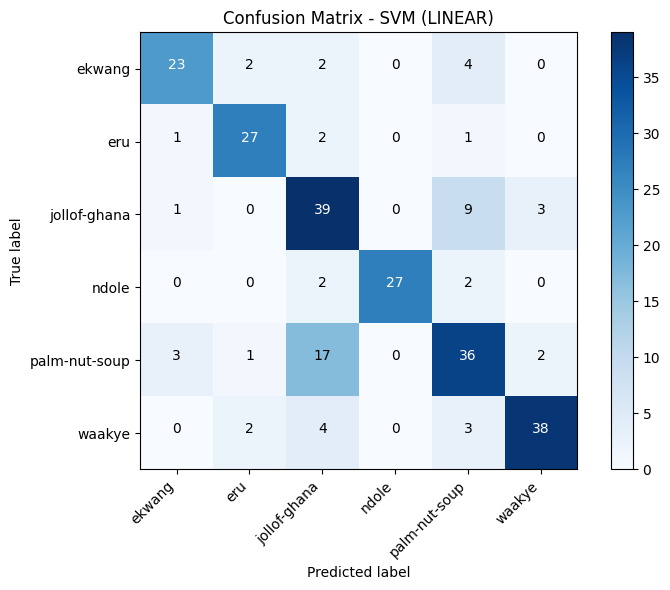


=== Training SVM dengan kernel: POLY ===
Confusion Matrix:
[[23  4  2  0  2  0]
 [ 0 28  1  0  1  1]
 [ 0  0 40  0  9  3]
 [ 0  1  2 27  1  0]
 [ 2  1  9  0 45  2]
 [ 0  1  3  0  4 39]]

Classification Report:
               precision    recall  f1-score   support

       ekwang     0.9200    0.7419    0.8214        31
          eru     0.8000    0.9032    0.8485        31
 jollof-ghana     0.7018    0.7692    0.7339        52
        ndole     1.0000    0.8710    0.9310        31
palm-nut-soup     0.7258    0.7627    0.7438        59
       waakye     0.8667    0.8298    0.8478        47

     accuracy                         0.8048       251
    macro avg     0.8357    0.8130    0.8211       251
 weighted avg     0.8142    0.8048    0.8069       251

Akurasi untuk kernel 'poly': 0.8048


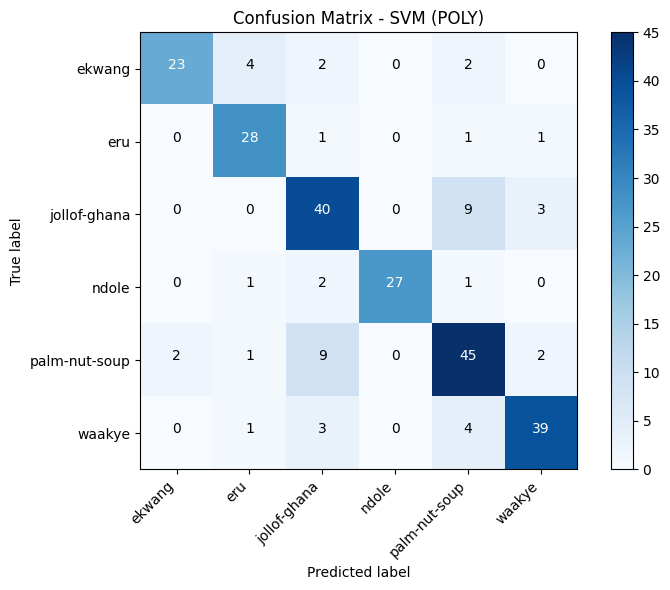


=== Training SVM dengan kernel: SIGMOID ===
Confusion Matrix:
[[ 0 10 17  0  4  0]
 [ 0  2 29  0  0  0]
 [ 0 31 15  0  6  0]
 [ 0 25  6  0  0  0]
 [ 0 19 31  0  9  0]
 [ 0 17 28  0  2  0]]

Classification Report:
               precision    recall  f1-score   support

       ekwang     0.0000    0.0000    0.0000        31
          eru     0.0192    0.0645    0.0296        31
 jollof-ghana     0.1190    0.2885    0.1685        52
        ndole     0.0000    0.0000    0.0000        31
palm-nut-soup     0.4286    0.1525    0.2250        59
       waakye     0.0000    0.0000    0.0000        47

     accuracy                         0.1036       251
    macro avg     0.0945    0.0843    0.0705       251
 weighted avg     0.1278    0.1036    0.0915       251

Akurasi untuk kernel 'sigmoid': 0.1036


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


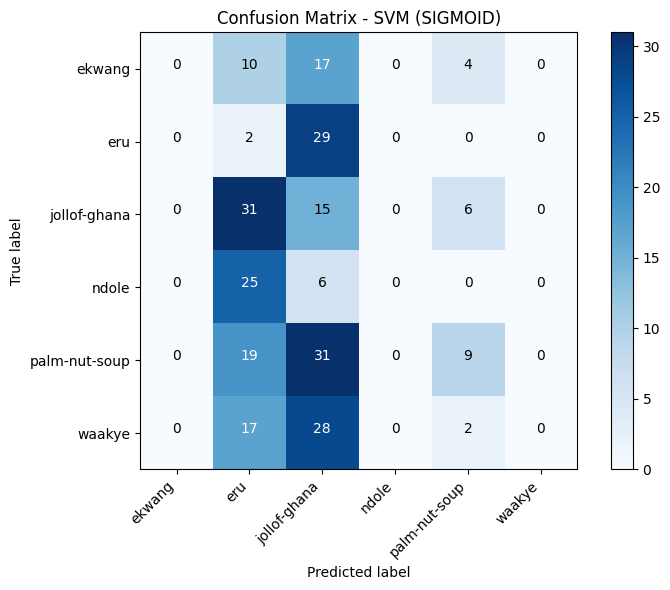


=== Perbandingan Akurasi antar Kernel ===
  LINEAR: 0.7570
    POLY: 0.8048
 SIGMOID: 0.1036


In [ ]:
# Tambahan evaluasi dengan semua kernel SVM utama
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Kernel yang akan diuji selain RBF (sudah dilakukan sebelumnya)
kernels = ['linear', 'poly', 'sigmoid']
accuracy_results = {}

for kernel_type in kernels:
    print(f"\n=== Training SVM dengan kernel: {kernel_type.upper()} ===")

    model = SVC(kernel=kernel_type, C=1.0, gamma='scale')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Confusion Matrix dan Akurasi
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[kernel_type] = acc

    print("Confusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    print(f"Akurasi untuk kernel '{kernel_type}': {acc:.4f}")

    # Visualisasi Confusion Matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(f"Confusion Matrix - SVM ({kernel_type.upper()})")
    plt.colorbar()
    tick_marks = np.arange(len(model.classes_))
    plt.xticks(tick_marks, model.classes_, rotation=45, ha='right')
    plt.yticks(tick_marks, model.classes_)

    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Tampilkan perbandingan akurasi antar kernel
print("\n=== Perbandingan Akurasi antar Kernel ===")
for k, v in accuracy_results.items():
    print(f"{k.upper():>8}: {v:.4f}")

Membuat Radar Chart...


<ipython-input-4-1917332380>:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(df))


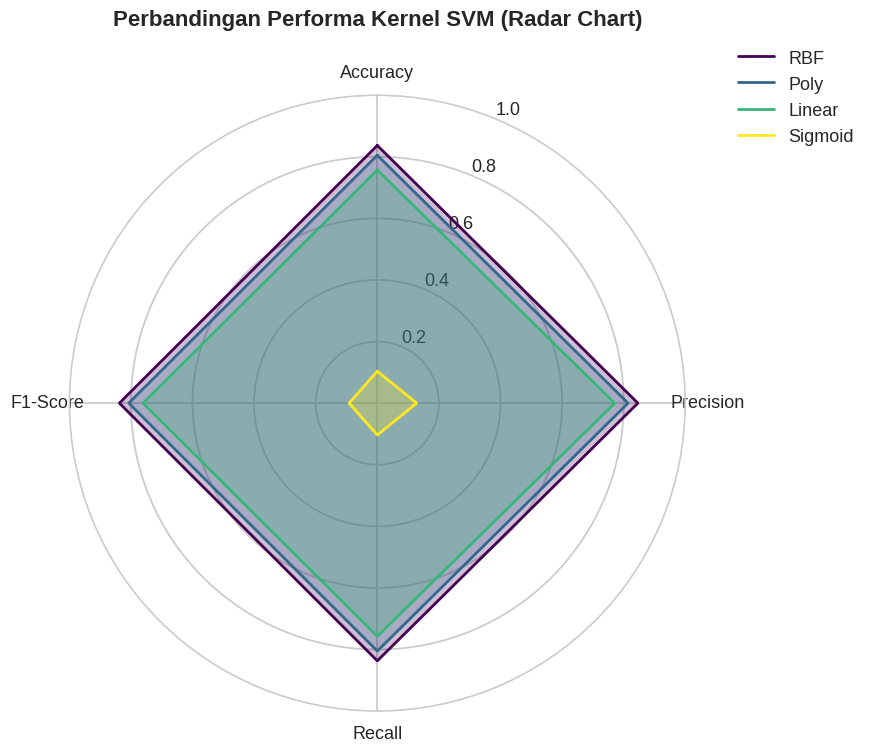


Membuat Grouped Bar Chart...


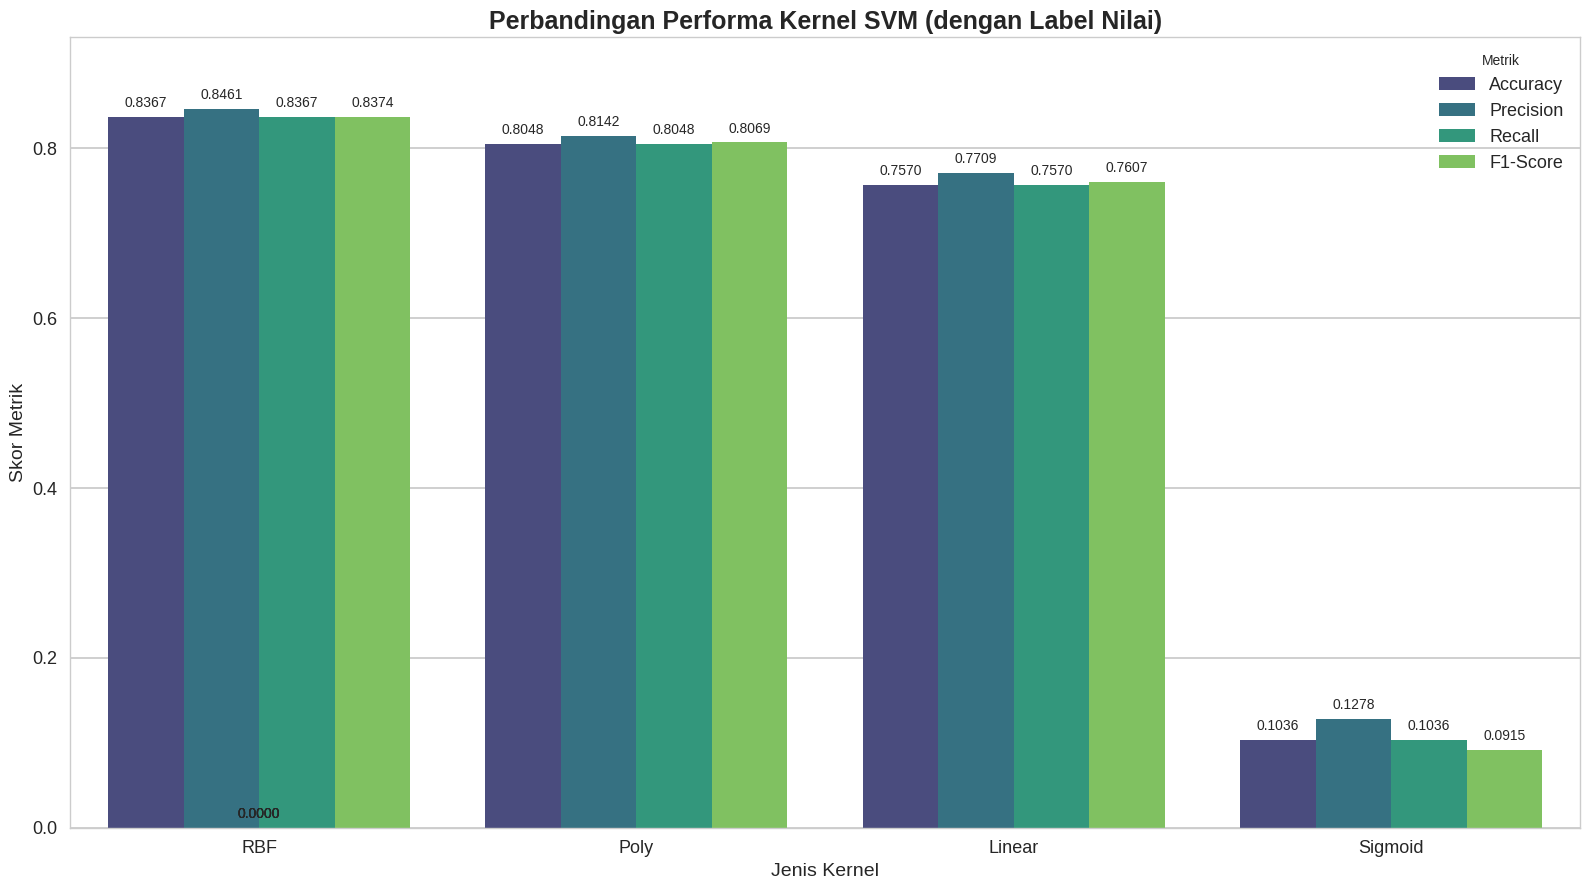


Tabel Detail Performa Kernel
 Kernel  Accuracy  Precision  Recall  F1-Score
    RBF    0.8367     0.8461  0.8367    0.8374
   Poly    0.8048     0.8142  0.8048    0.8069
 Linear    0.7570     0.7709  0.7570    0.7607
Sigmoid    0.1036     0.1278  0.1036    0.0915


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_radar_chart(df: pd.DataFrame):
    """
    Membuat dan menampilkan visualisasi Radar Chart dari data performa kernel.
    """
    print("Membuat Radar Chart...")

    # Mendefinisikan label dan sudut untuk setiap sumbu pada chart
    labels = df.columns[1:]
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Menutup lingkaran chart

    # Membuat figure dan axes untuk plot dengan proyeksi polar
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.style.use('seaborn-v0_8-whitegrid')

    # Mendefinisikan palet warna yang akan digunakan
    colors = plt.cm.get_cmap('viridis', len(df))

    # Loop untuk mem-plot data performa dari setiap kernel
    for i, kernel_name in enumerate(df['Kernel']):
        # Mengambil nilai performa untuk satu kernel
        values = df.loc[df['Kernel'] == kernel_name, labels].values.flatten().tolist()
        values += values[:1] # Menutup poligon

        # Menggambar garis plot pada chart
        ax.plot(angles, values, color=colors(i), linewidth=2, linestyle='solid', label=kernel_name)
        # Memberi warna pada area di dalam poligon
        ax.fill(angles, values, color=colors(i), alpha=0.25)

    # Melakukan kustomisasi pada tampilan chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, 1.0) # Mengatur batas sumbu radial
    ax.set_title('Perbandingan Performa Kernel SVM (Radar Chart)', size=16, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

    # Menampilkan chart
    plt.show()

def plot_grouped_bar_chart(df: pd.DataFrame):
    """
    Membuat dan menampilkan visualisasi Grouped Bar Chart dengan label nilai.
    """
    print("\nMembuat Grouped Bar Chart...")

    # Mengubah format DataFrame dari 'wide' ke 'long' agar sesuai untuk Seaborn
    df_melted = df.melt(id_vars="Kernel", var_name="Metric", value_name="Score")

    # Membuat figure dan axes untuk plot
    plt.style.use('seaborn-v0_8-talk')
    fig, ax = plt.subplots(figsize=(16, 9))

    # Membuat bar plot menggunakan Seaborn
    splot = sns.barplot(x="Kernel", y="Score", hue="Metric", data=df_melted, palette='viridis', ax=ax)

    # Loop untuk menambahkan label angka pada setiap bar
    for bar in splot.patches:
        # Lanjutkan jika bar tidak memiliki tinggi (untuk menghindari error)
        if np.isnan(bar.get_height()):
            continue

        # Menambahkan teks label dengan format 4 desimal
        splot.annotate(f'{bar.get_height():.4f}',
                       (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                       ha='center', va='bottom',
                       size=10,
                       xytext=(0, 5),
                       textcoords='offset points')

    # Melakukan kustomisasi pada tampilan chart
    max_score = df_melted['Score'].max()
    ax.set_ylim(0, max_score * 1.1) # Memberi ruang untuk label di atas bar tertinggi
    ax.set_title('Perbandingan Performa Kernel SVM (dengan Label Nilai)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Jenis Kernel', fontsize=14)
    ax.set_ylabel('Skor Metrik', fontsize=14)
    ax.legend(title='Metrik')
    plt.xticks(rotation=0)
    plt.tight_layout()

    # Menampilkan chart
    plt.show()

def display_performance_table(df: pd.DataFrame):
    """
    Menampilkan data performa dalam bentuk tabel yang terformat.
    """
    print("\n" + "="*40)
    print("Tabel Detail Performa Kernel")
    print("="*40)
    pd.set_option('display.float_format', '{:.4f}'.format)
    print(df.to_string(index=False))
    print("="*40)

if __name__ == '__main__':
    # Mendefinisikan data mentah performa dari setiap kernel
    raw_data = {
        'Kernel': ['RBF', 'Poly', 'Linear', 'Sigmoid'],
        'Accuracy': [0.8367, 0.8048, 0.7570, 0.1036],
        'Precision': [0.8461, 0.8142, 0.7709, 0.1278],
        'Recall': [0.8367, 0.8048, 0.7570, 0.1036],
        'F1-Score': [0.8374, 0.8069, 0.7607, 0.0915]
    }

    # Membuat DataFrame dari data mentah menggunakan pandas
    performance_df = pd.DataFrame(raw_data)

    # Memanggil fungsi untuk membuat dan menampilkan Radar Chart
    plot_radar_chart(performance_df)

    # Memanggil fungsi untuk membuat dan menampilkan Grouped Bar Chart
    plot_grouped_bar_chart(performance_df)

    # Memanggil fungsi untuk menampilkan tabel hasil performa
    display_performance_table(performance_df)

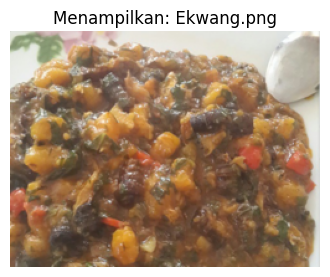

Gambar: Ekwang.png  →  Prediksi: ekwang


In [ ]:
# 9. Test data baru
from PIL import Image
import matplotlib.pyplot as plt
import os

new_data = '/content/drive/MyDrive/UAS ML Teo 2025/Ekwang.png'

# Tampilkan gambar
img = Image.open(new_data).convert('RGB')
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title(f"Menampilkan: {os.path.basename(new_data)}")
plt.show()

# Prediksi kelas
x_single = load_and_preprocess(new_data).reshape(1, -1)
y_single_pred = svm_model.predict(x_single)
print(f"Gambar: {os.path.basename(new_data)}  →  Prediksi: {y_single_pred[0]}")